In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
malr_file = "D:/5.2/Project/Data/gsp_cov_2020/gsp_cov_2020.shp"
gdf = gpd.read_file(malr_file).dropna()
gdf.to_csv('malaria.csv')

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

def visualize_malaria_indicators(gdf, year):
    short = year[-2:]  # e.g., '15' for 2015

    # Get MI and MP columns
    mi_col = f'MI_{short}'
    mp_col = f'MP_{short}'

    # Filter all year-specific columns
    year_cols = [col for col in gdf.columns if col.endswith(short) or col.endswith(year)]
    
    # Make sure MI and MP are present
    if mi_col not in year_cols or mp_col not in year_cols:
        print(f"❌ MI or MP columns missing for year {year}")
        return

    features = [col for col in year_cols if col not in [mi_col, mp_col]]
    subset = gdf[[mi_col, mp_col] + features].dropna()

    if subset.empty:
        print(f"❌ No data available for year {year}")
        return

    # -----------------------------
    # 1. Correlation Heatmap
    # -----------------------------
    plt.figure(figsize=(12, 8))
    corr = subset.corr()
    sns.heatmap(corr.loc[[mi_col, mp_col]], cmap='coolwarm', annot=True)
    plt.title(f'Correlation Heatmap (MI & MP) - {year}')
    plt.show()

    # -----------------------------
    # 2. Scatter Plots
    # -----------------------------
    for target in [mi_col, mp_col]:
        fig, axs = plt.subplots(nrows=(len(features) // 3 + 1), ncols=3, figsize=(18, len(features)*1.5))
        axs = axs.flatten()
        for i, feat in enumerate(features):
            axs[i].scatter(subset[feat], subset[target], alpha=0.5)
            axs[i].set_xlabel(feat)
            axs[i].set_ylabel(target)
        plt.suptitle(f'{target} vs Features - {year}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    # -----------------------------
    # 3. Feature Importance (Causal Proxy)
    # -----------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subset[features])
    
    for target in [mi_col, mp_col]:
        y = subset[target]
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_scaled, y)
        importances = model.feature_importances_

        sorted_idx = importances.argsort()[::-1][:10]  # top 10
        top_features = [features[i] for i in sorted_idx]
        top_scores = [importances[i] for i in sorted_idx]

        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_scores, y=top_features, palette='viridis')
        plt.title(f'Feature Importance for {target} - {year}')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.show()


In [14]:
import numpy as np

# Step 1: Replace string "NA" with actual NaN
gdf = gdf.replace("NA", np.nan)

# Step 2: Convert all columns that can be numeric
for col in gdf.columns:
    gdf[col] = pd.to_numeric(gdf[col], errors='ignore')


C:\Users\user\AppData\Local\Temp\ipykernel_7364\1097994354.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gdf[col] = pd.to_numeric(gdf[col], errors='ignore')


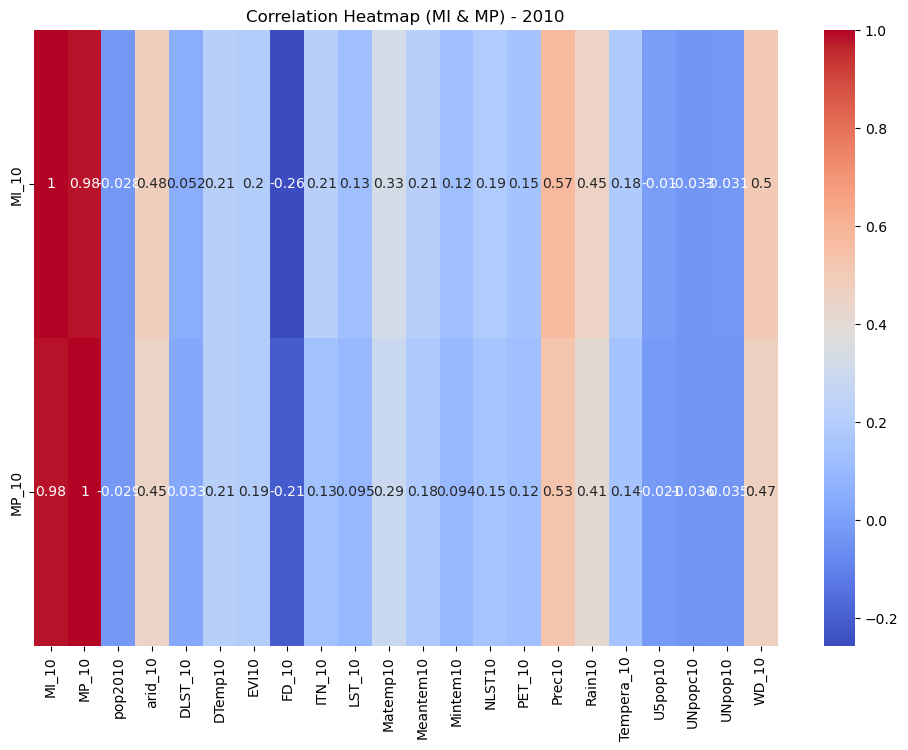

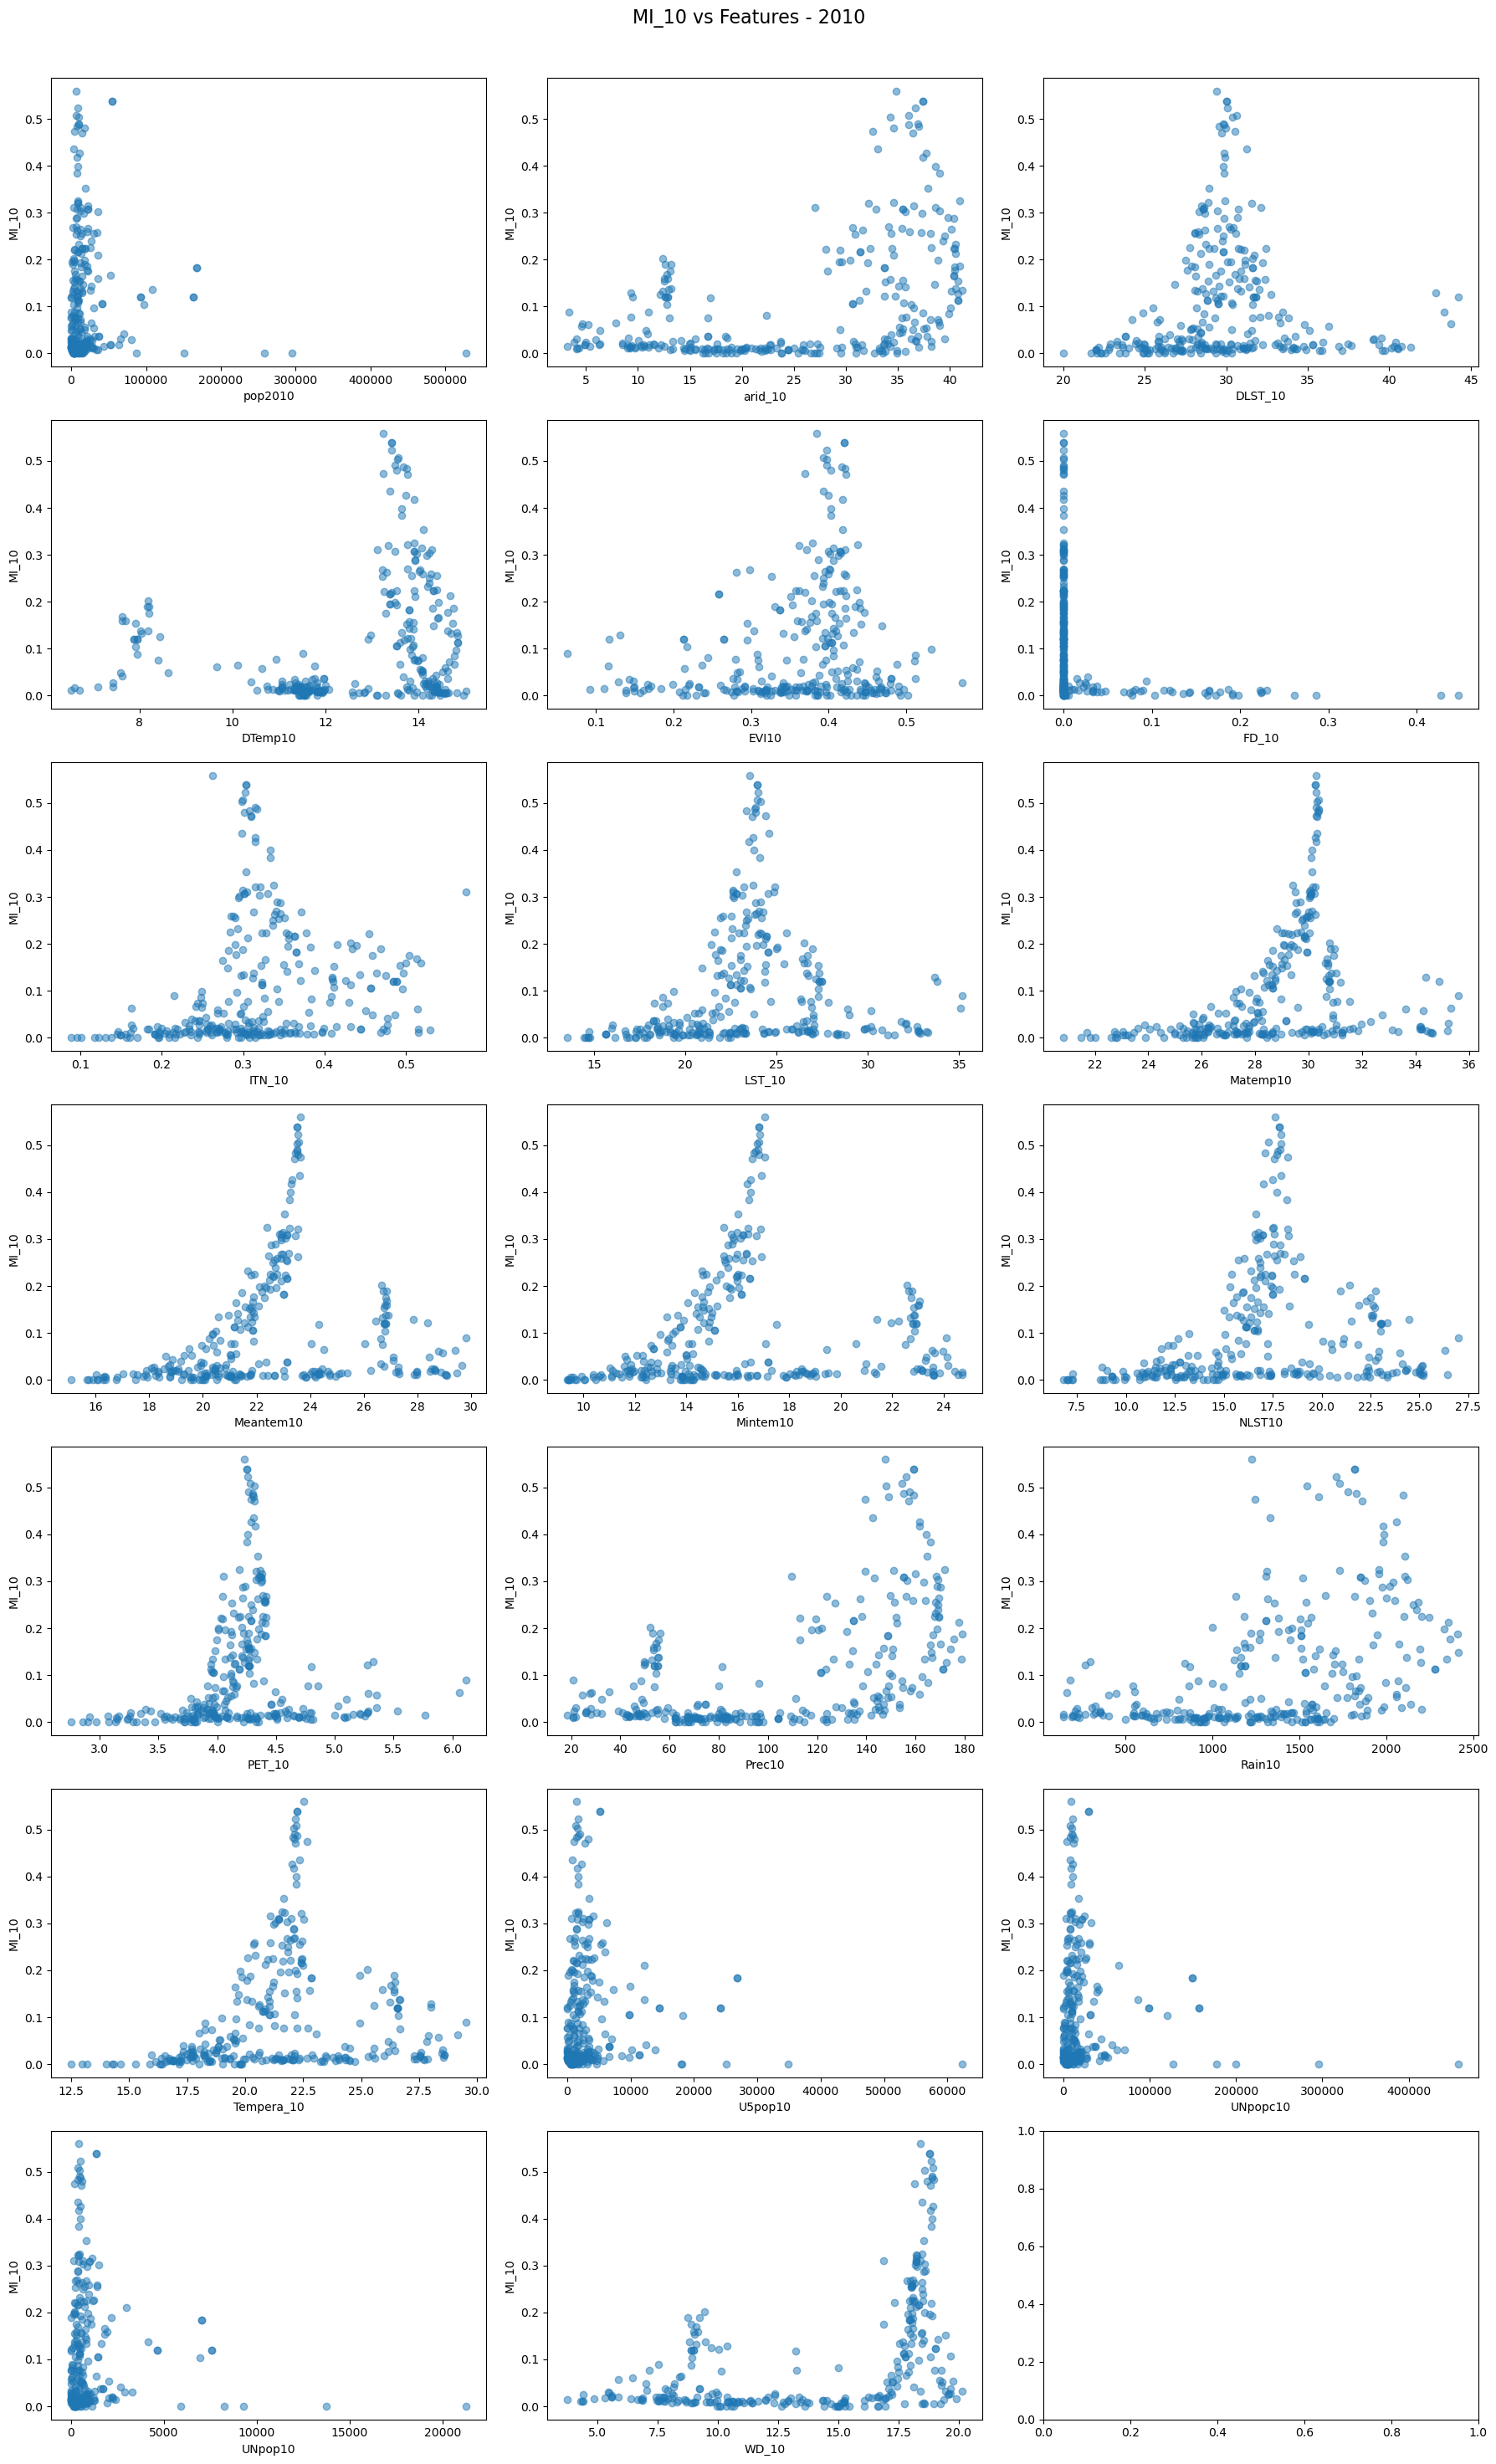

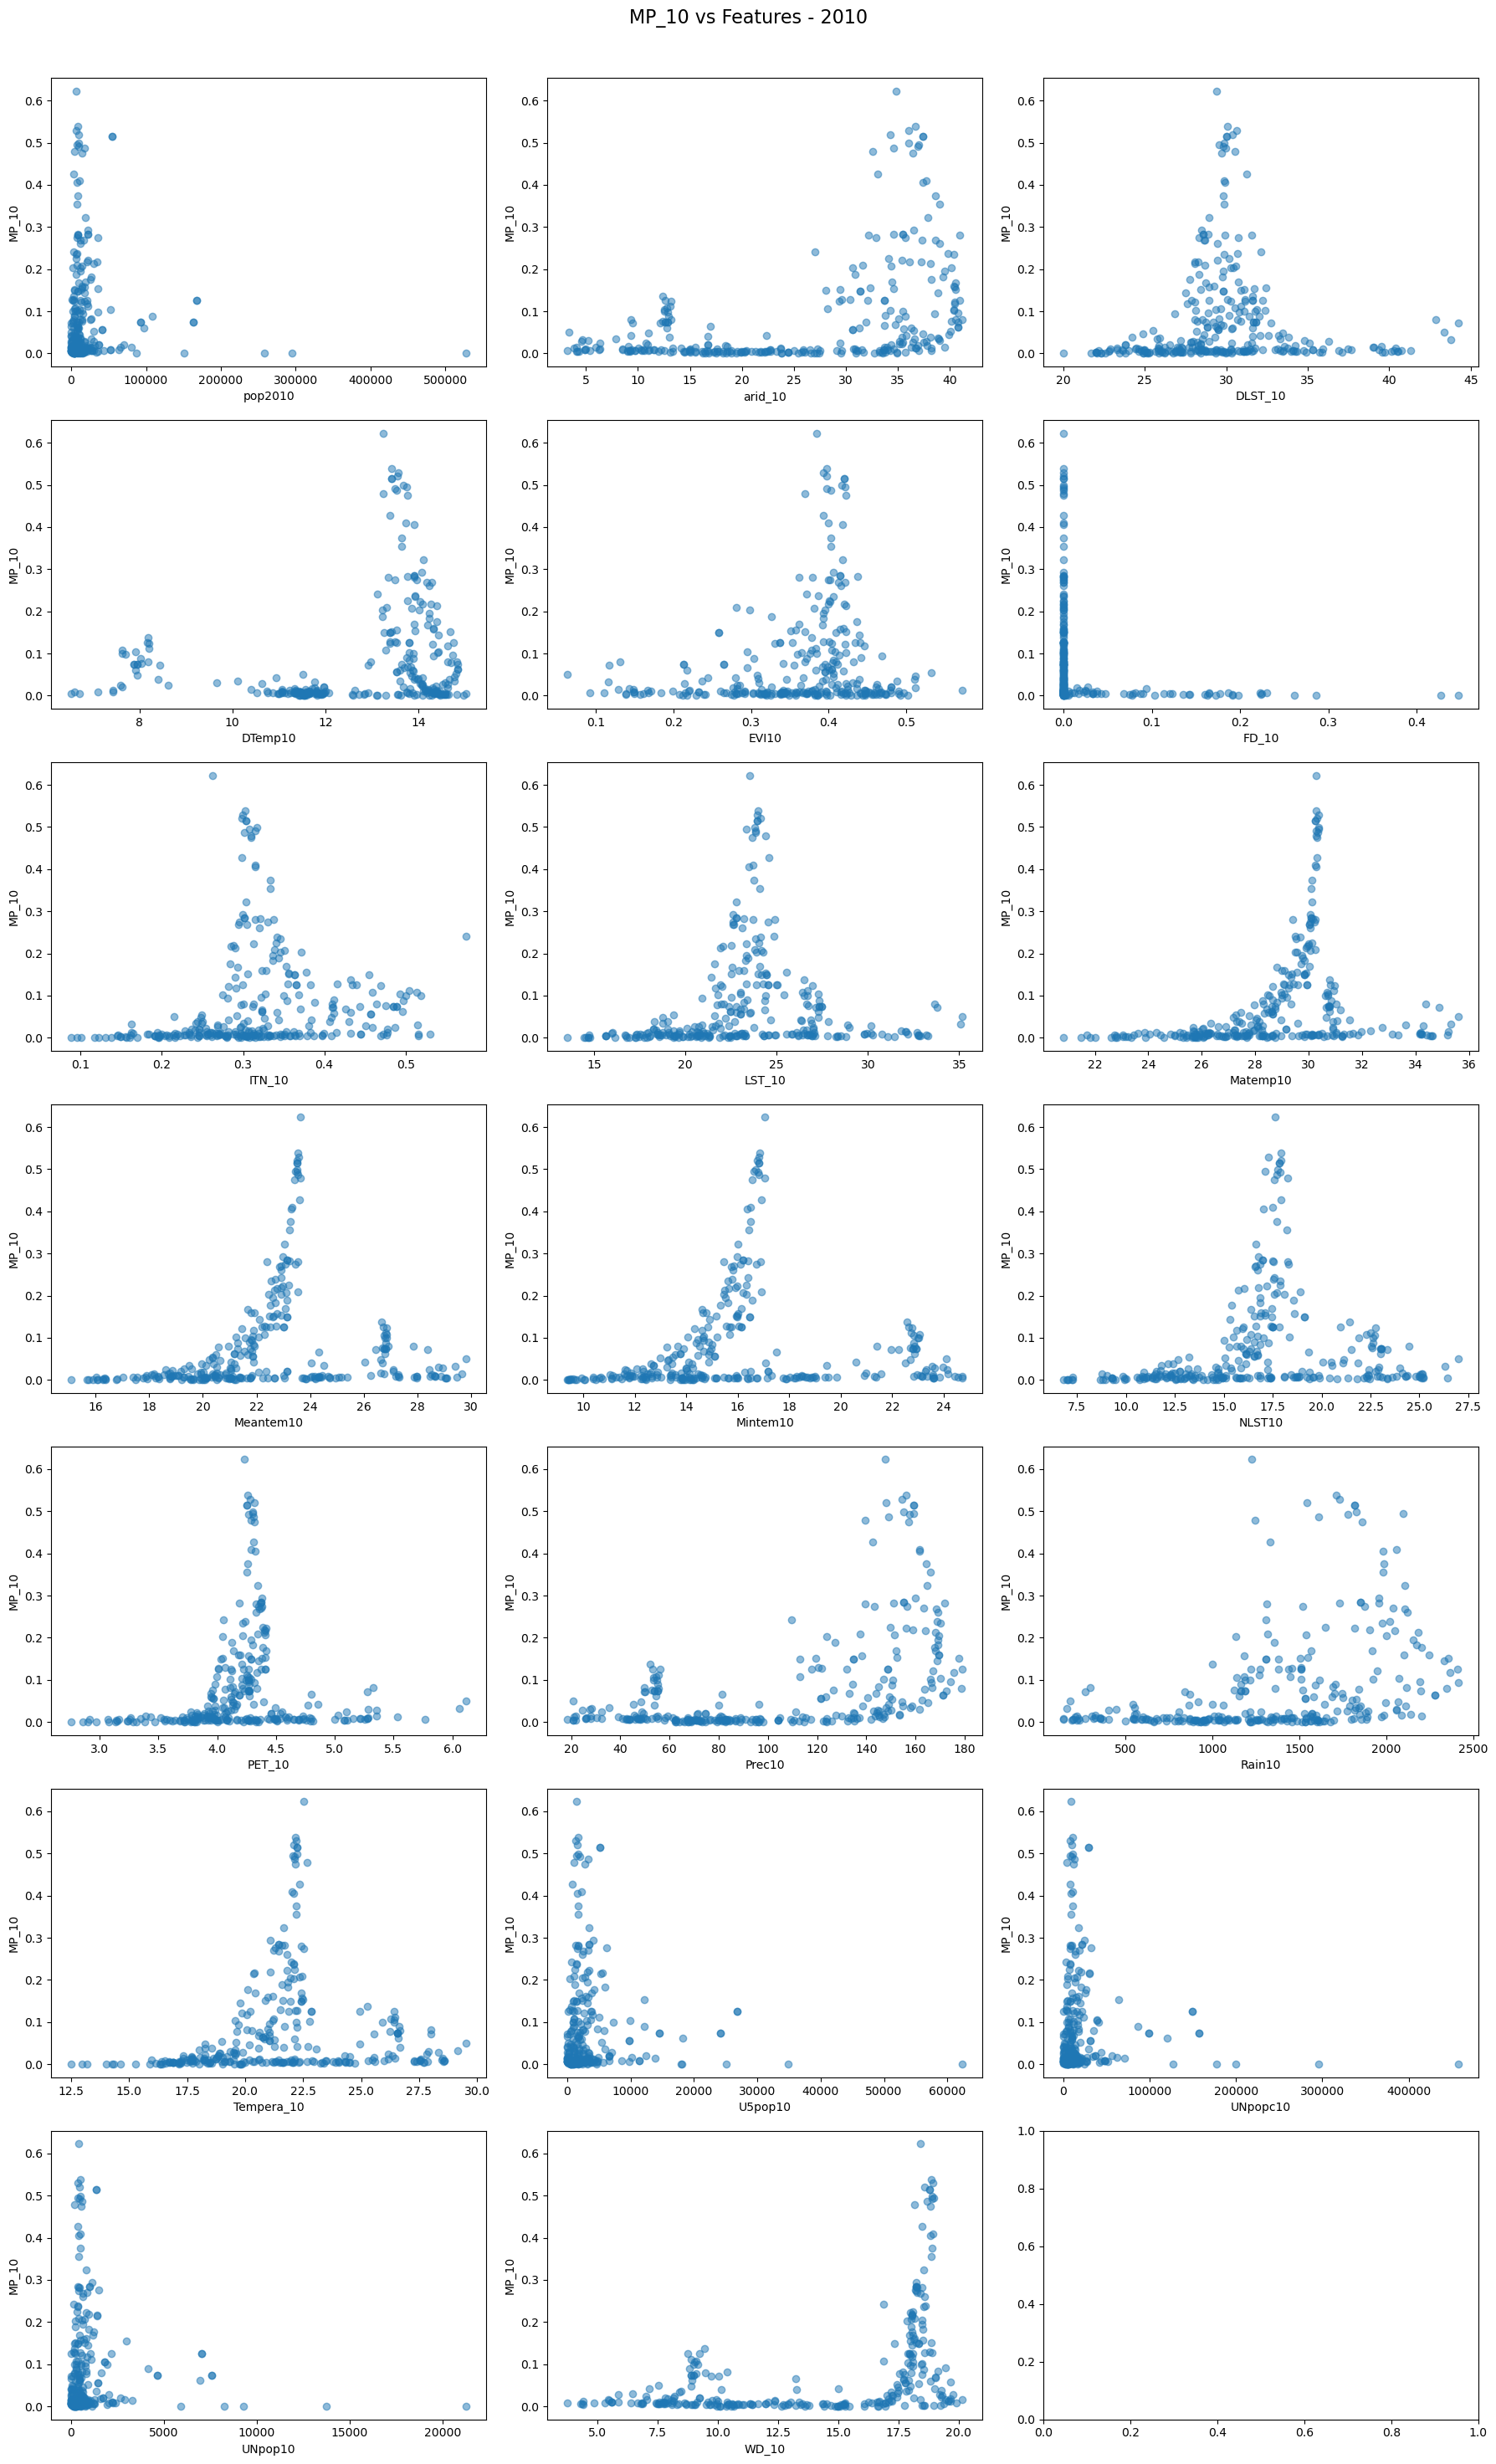

C:\Users\user\AppData\Local\Temp\ipykernel_7364\2164206489.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


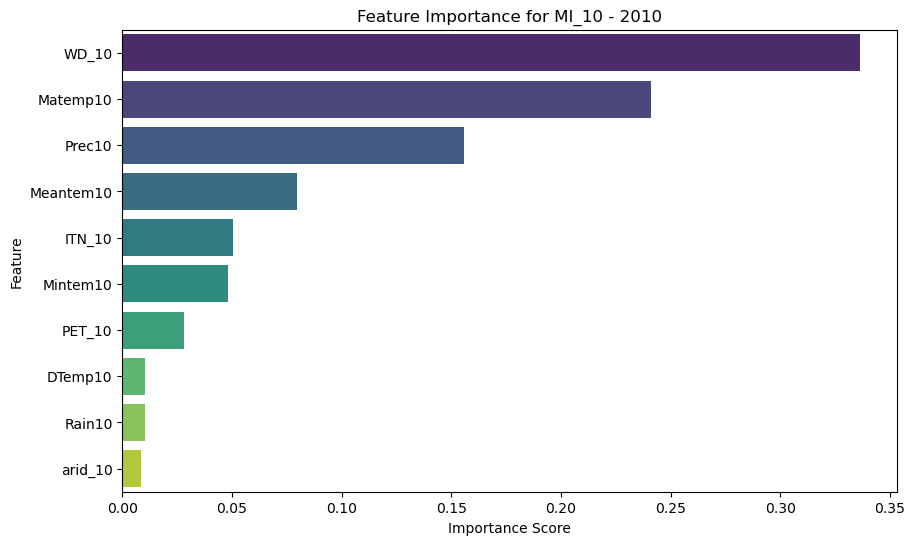

C:\Users\user\AppData\Local\Temp\ipykernel_7364\2164206489.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


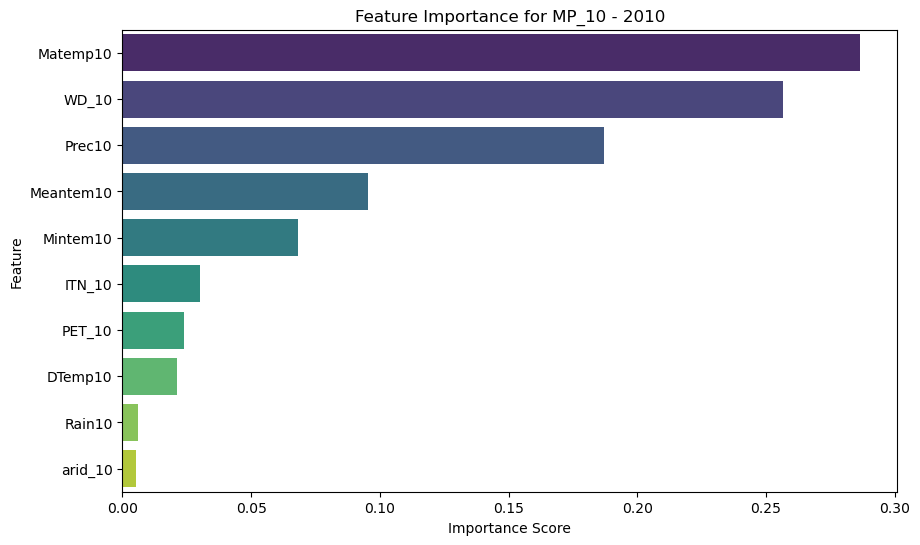

In [15]:
visualize_malaria_indicators(gdf, "2010")

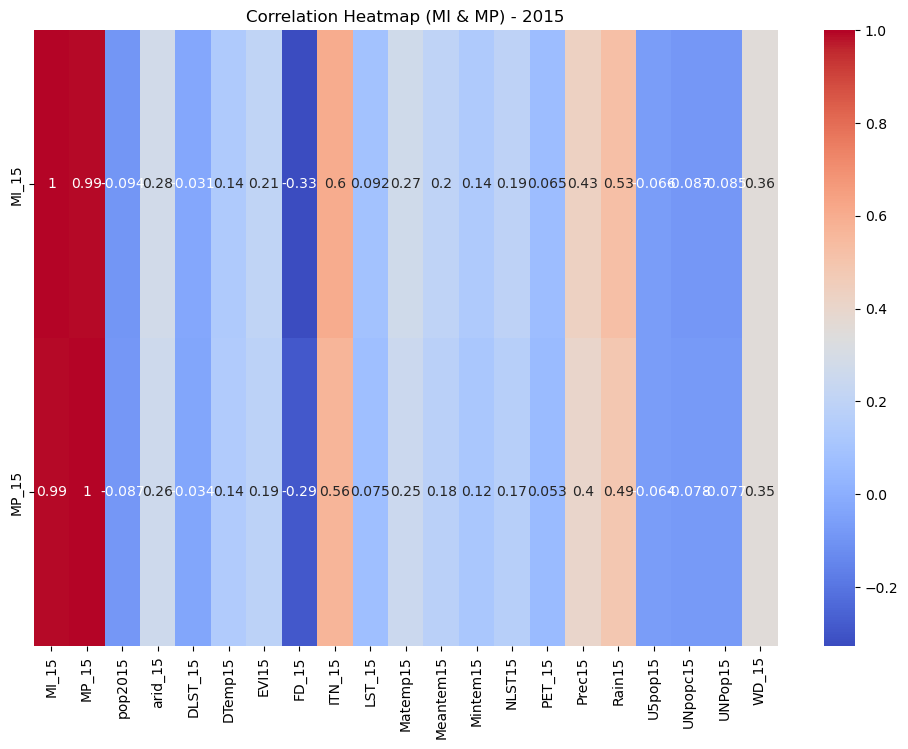

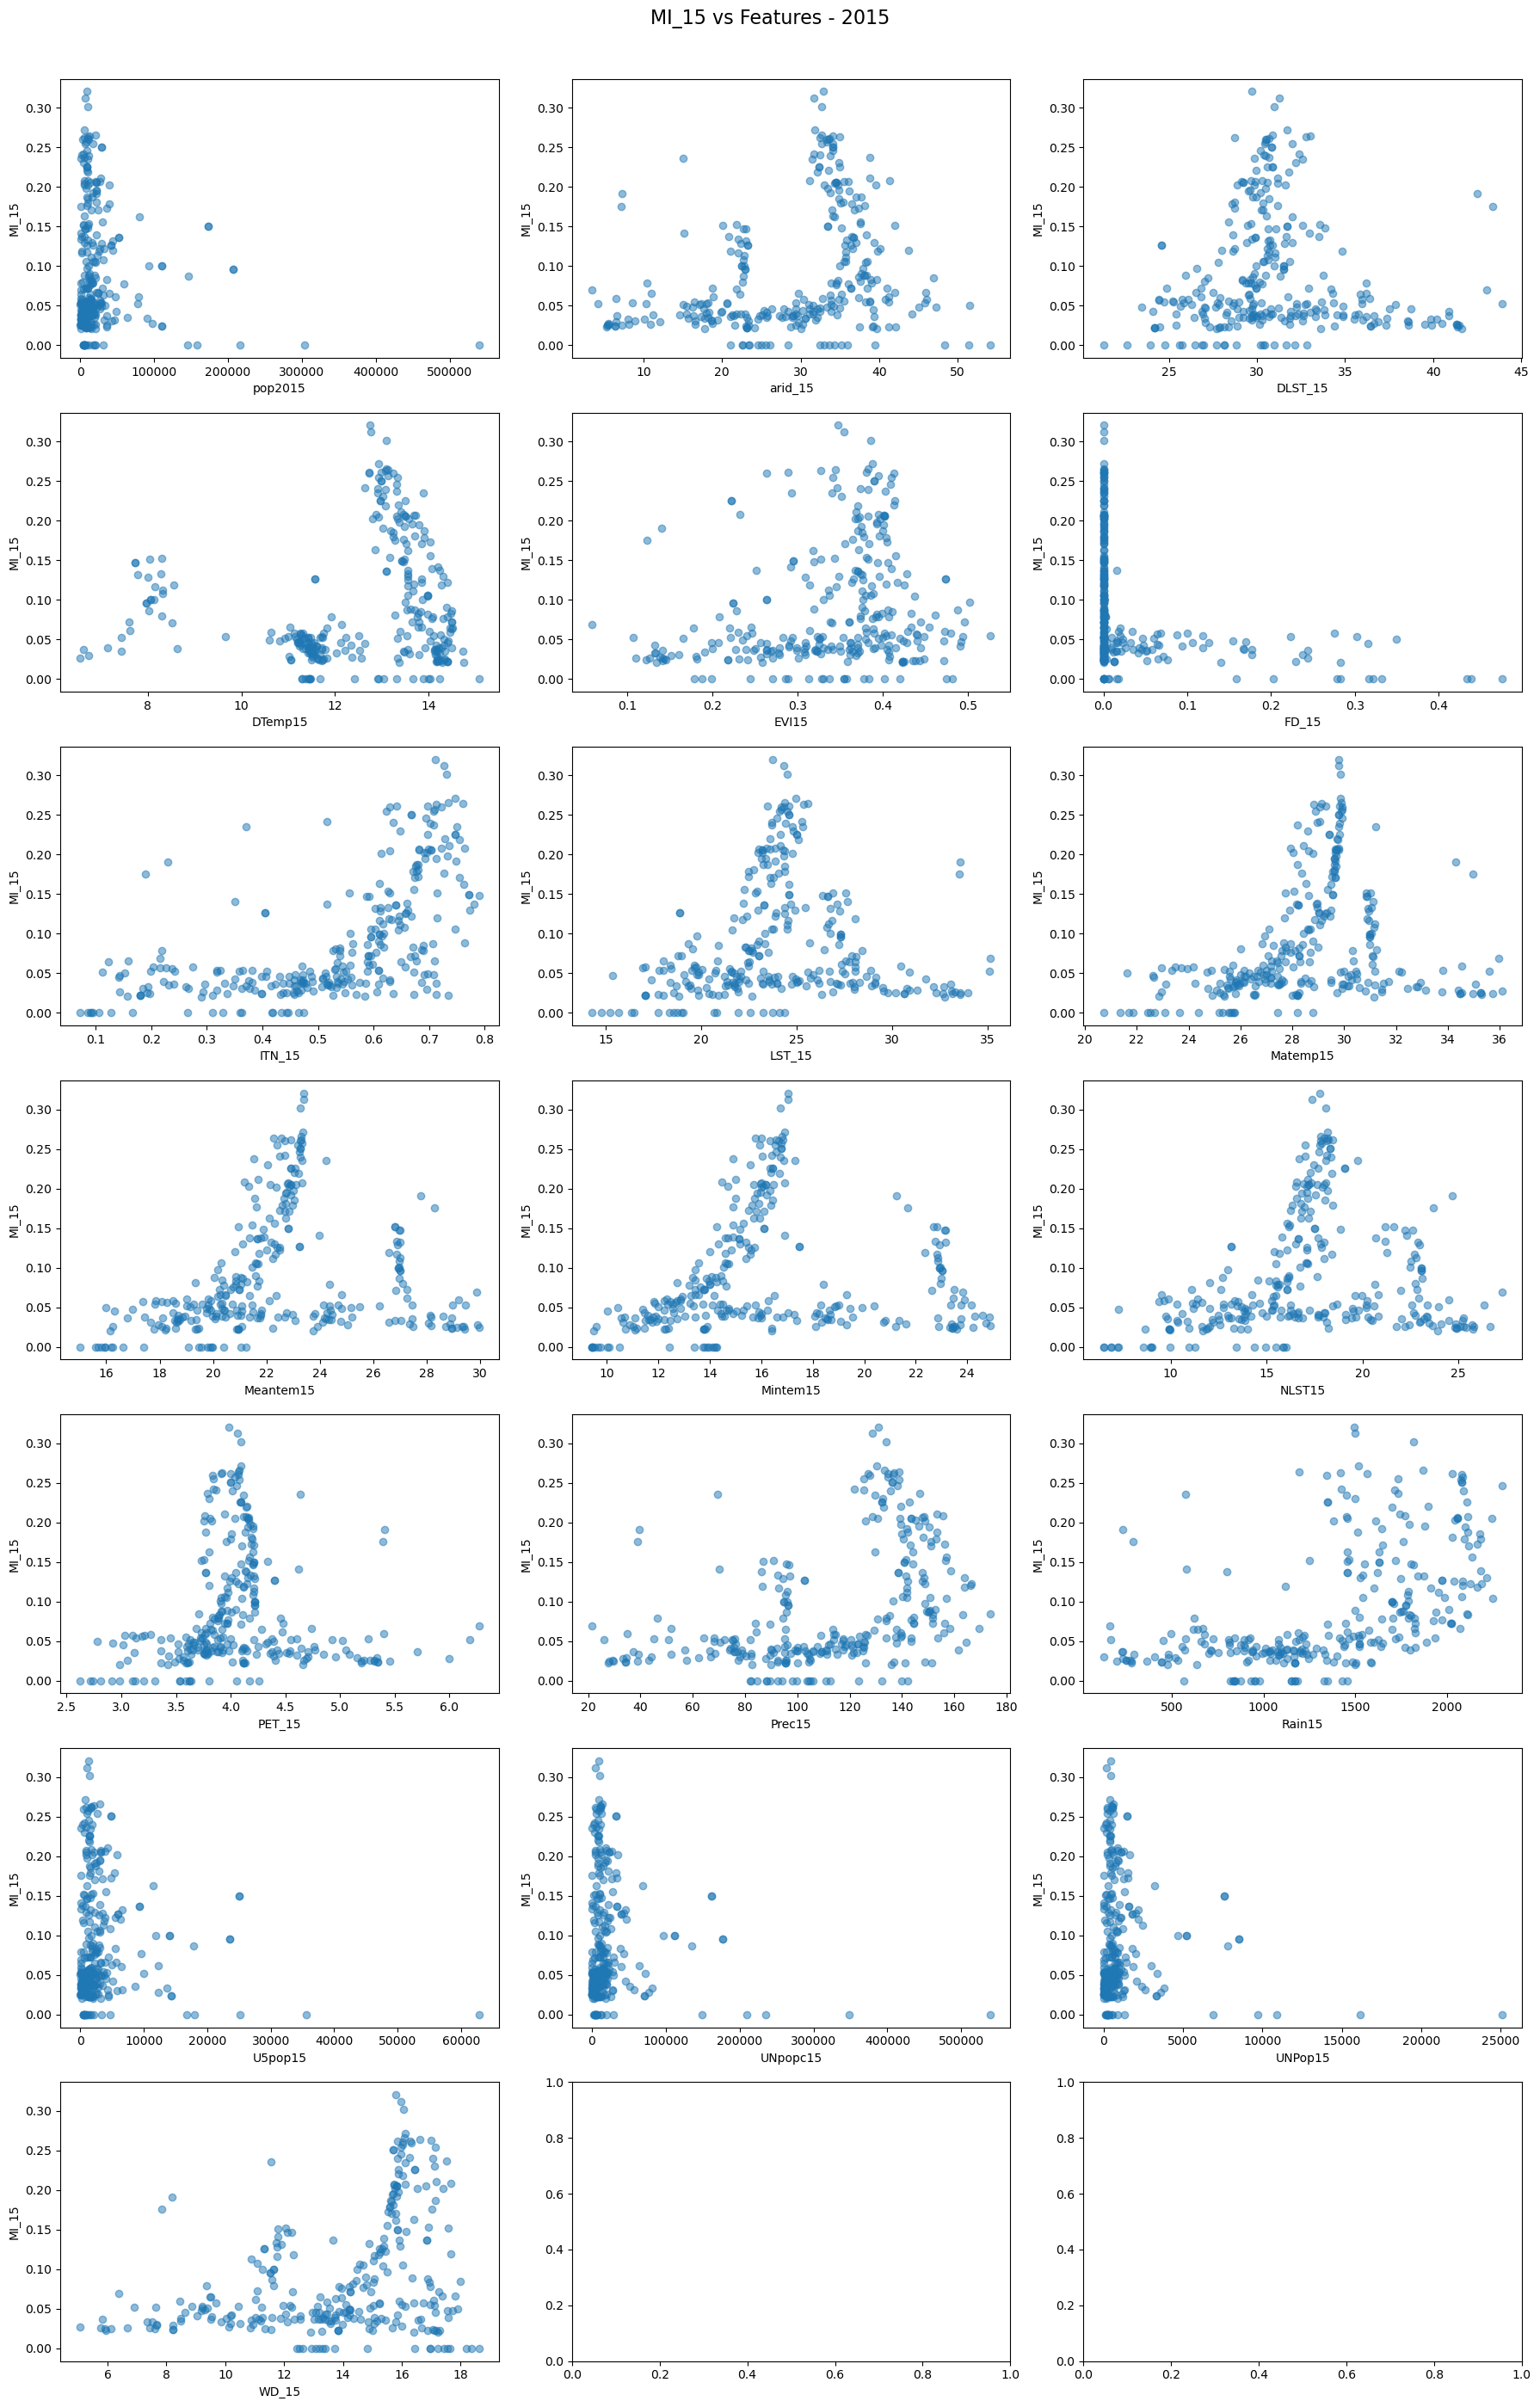

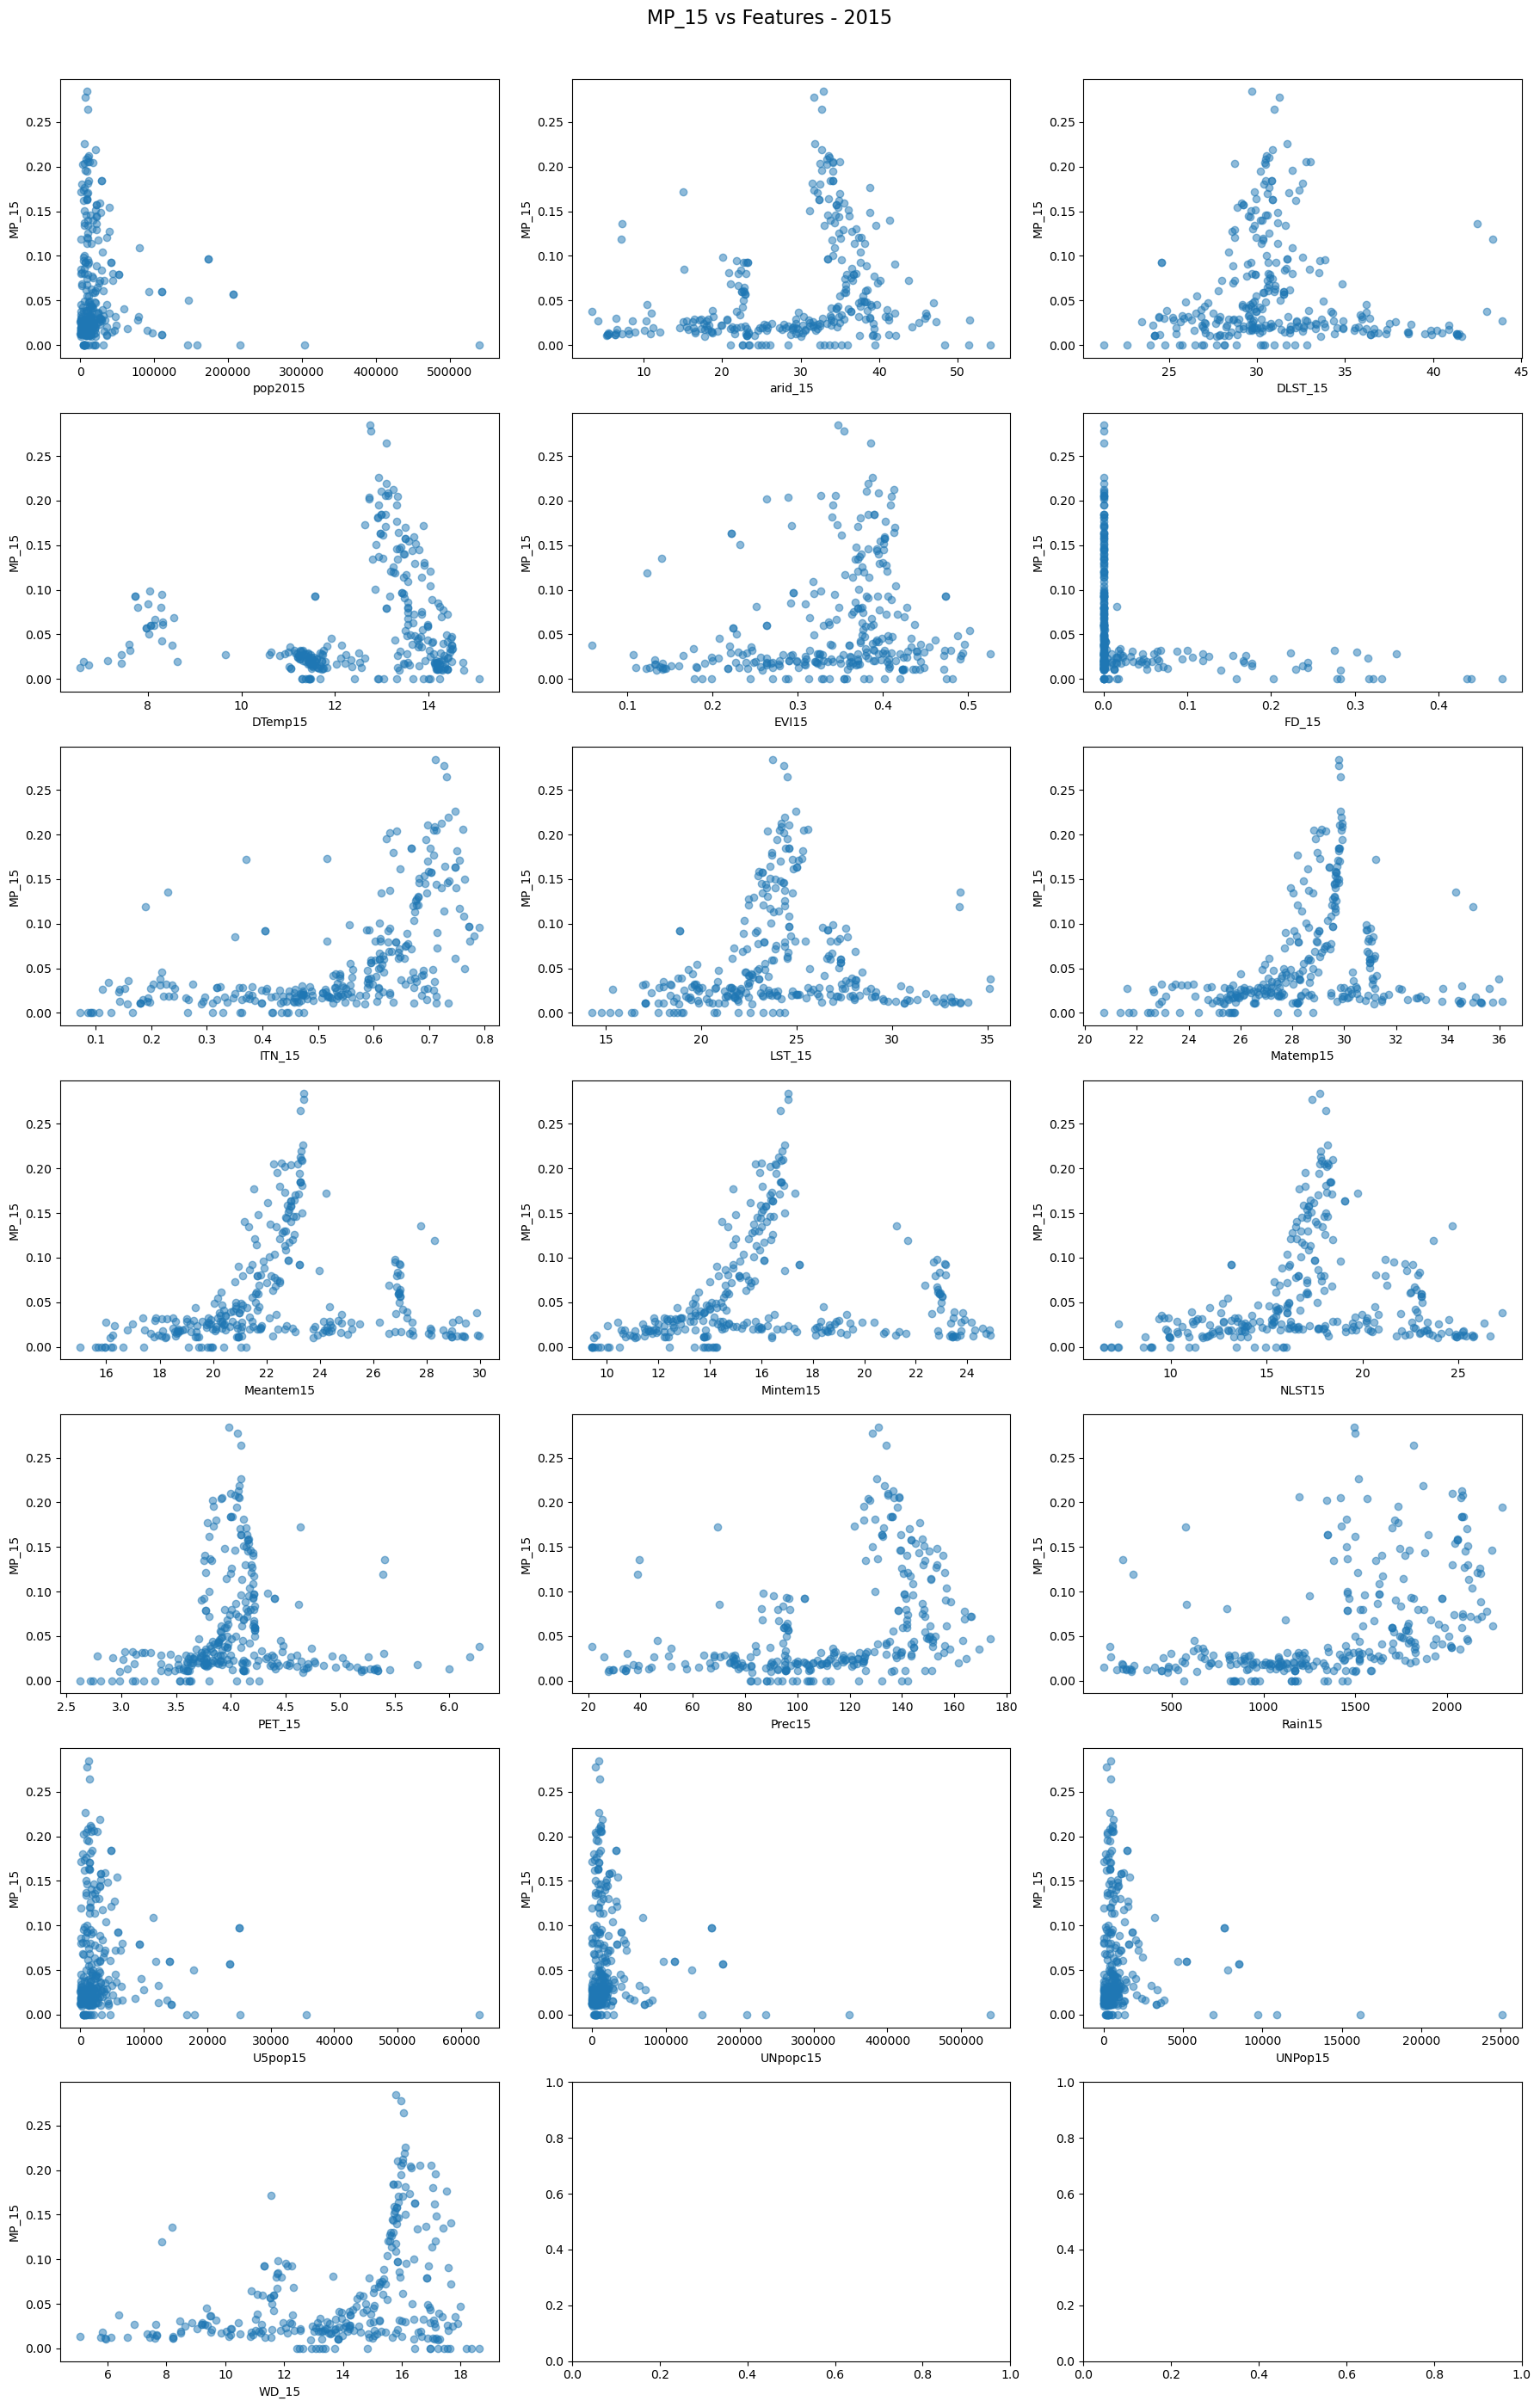

C:\Users\user\AppData\Local\Temp\ipykernel_7364\2164206489.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


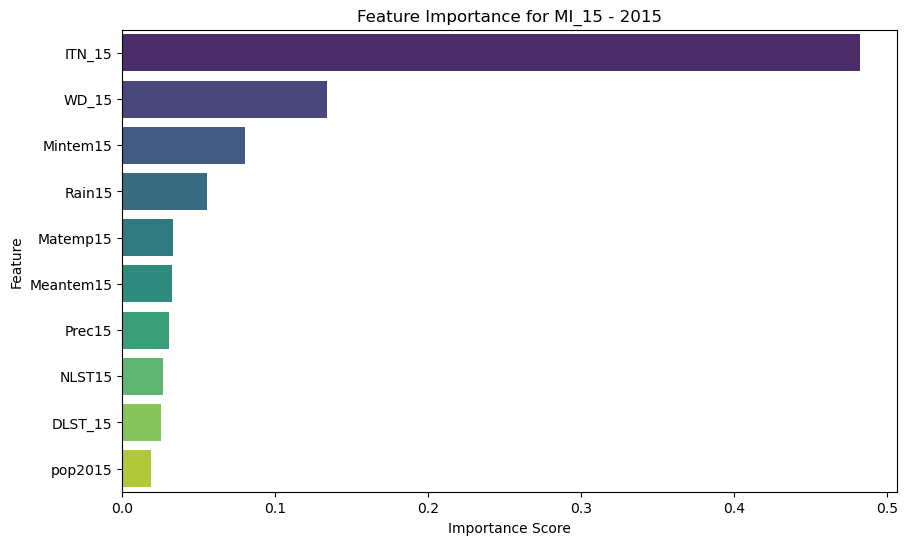

C:\Users\user\AppData\Local\Temp\ipykernel_7364\2164206489.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


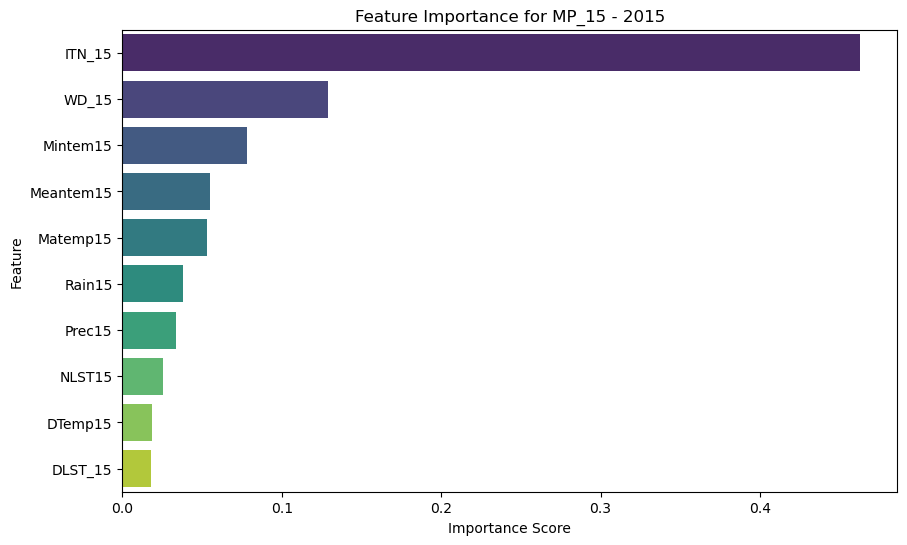

In [16]:
visualize_malaria_indicators(gdf, "2015")

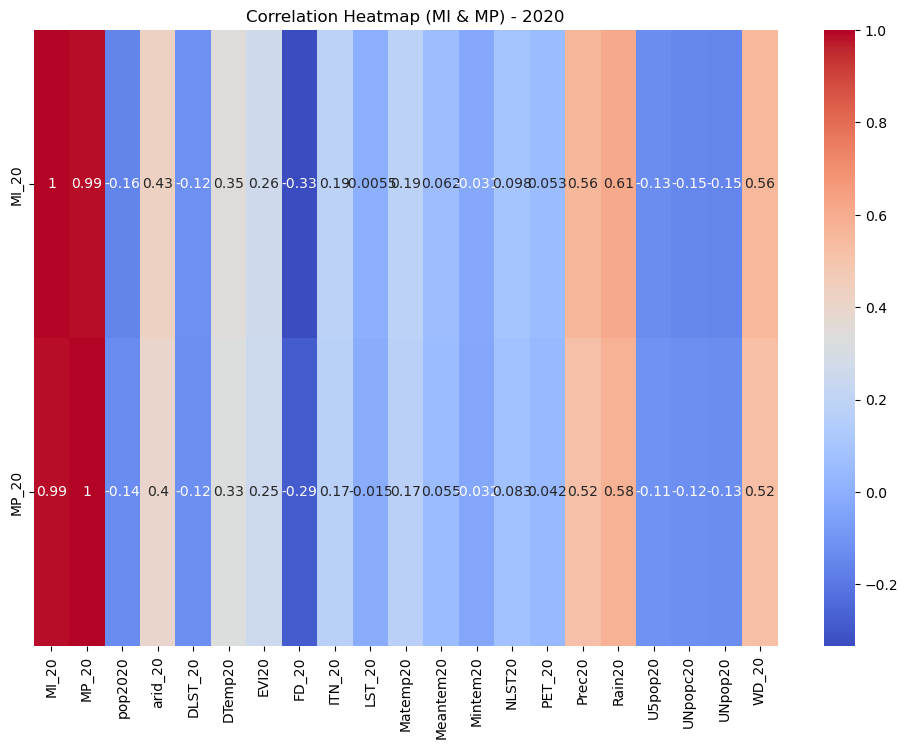

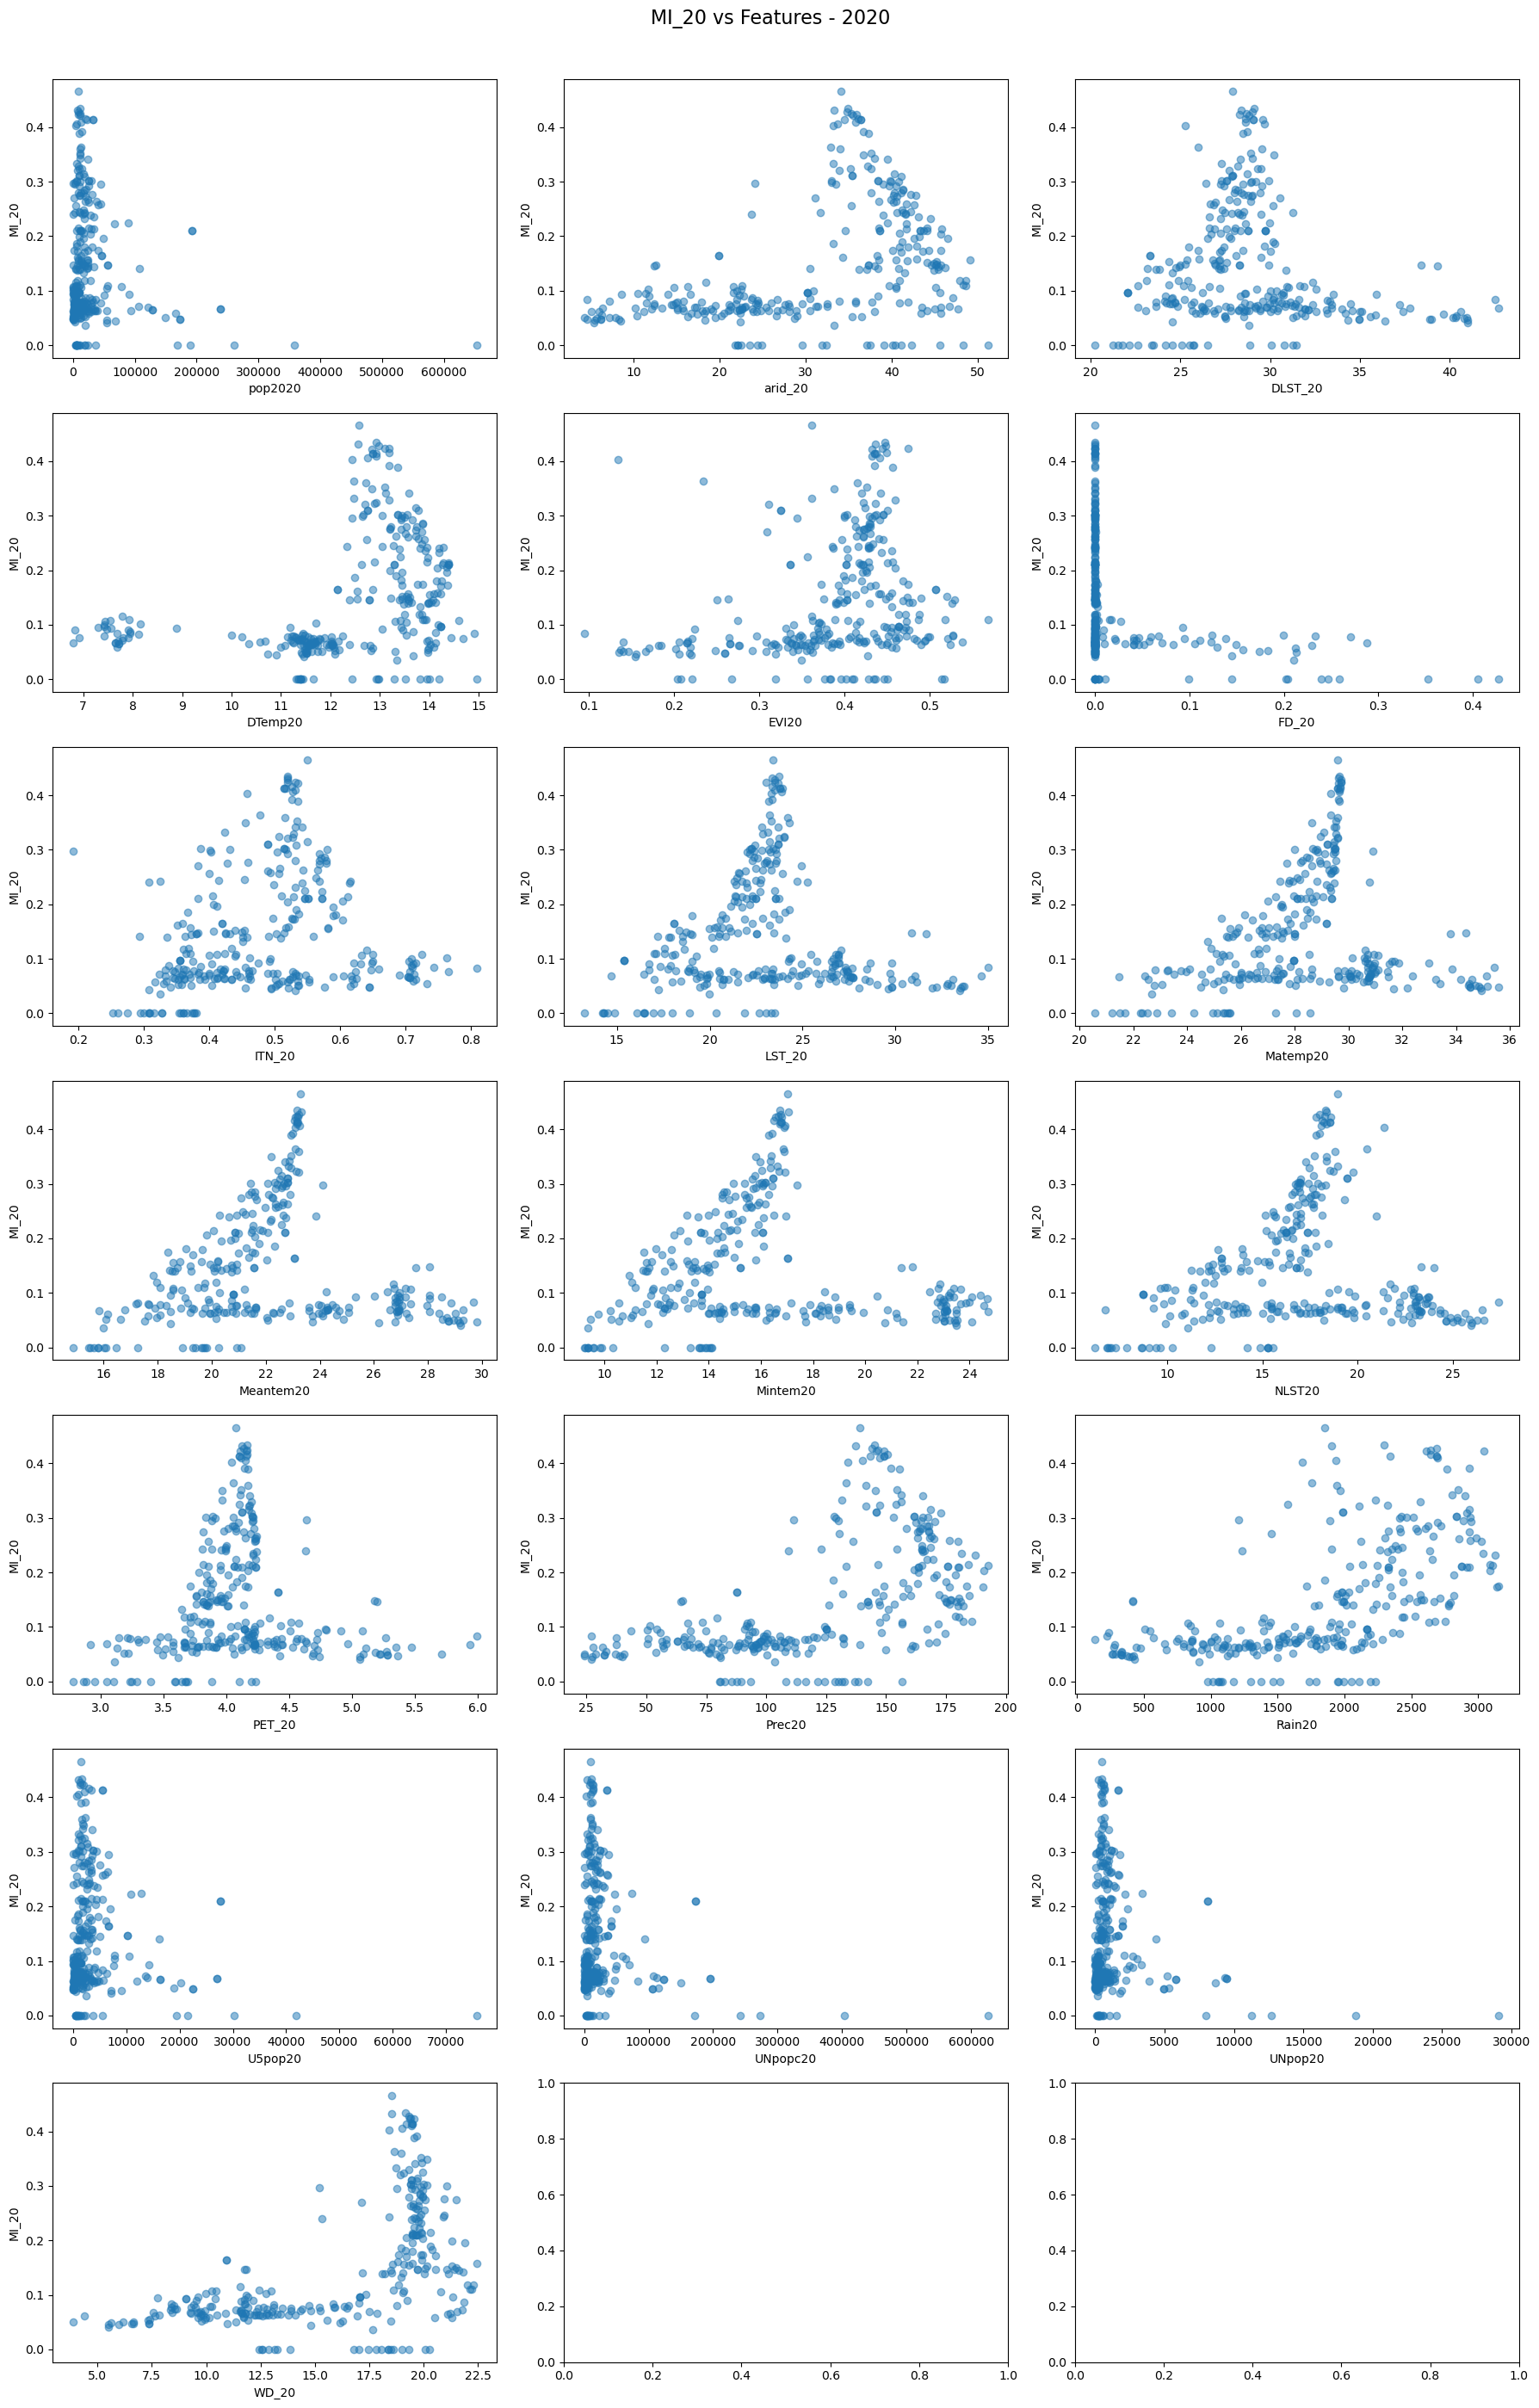

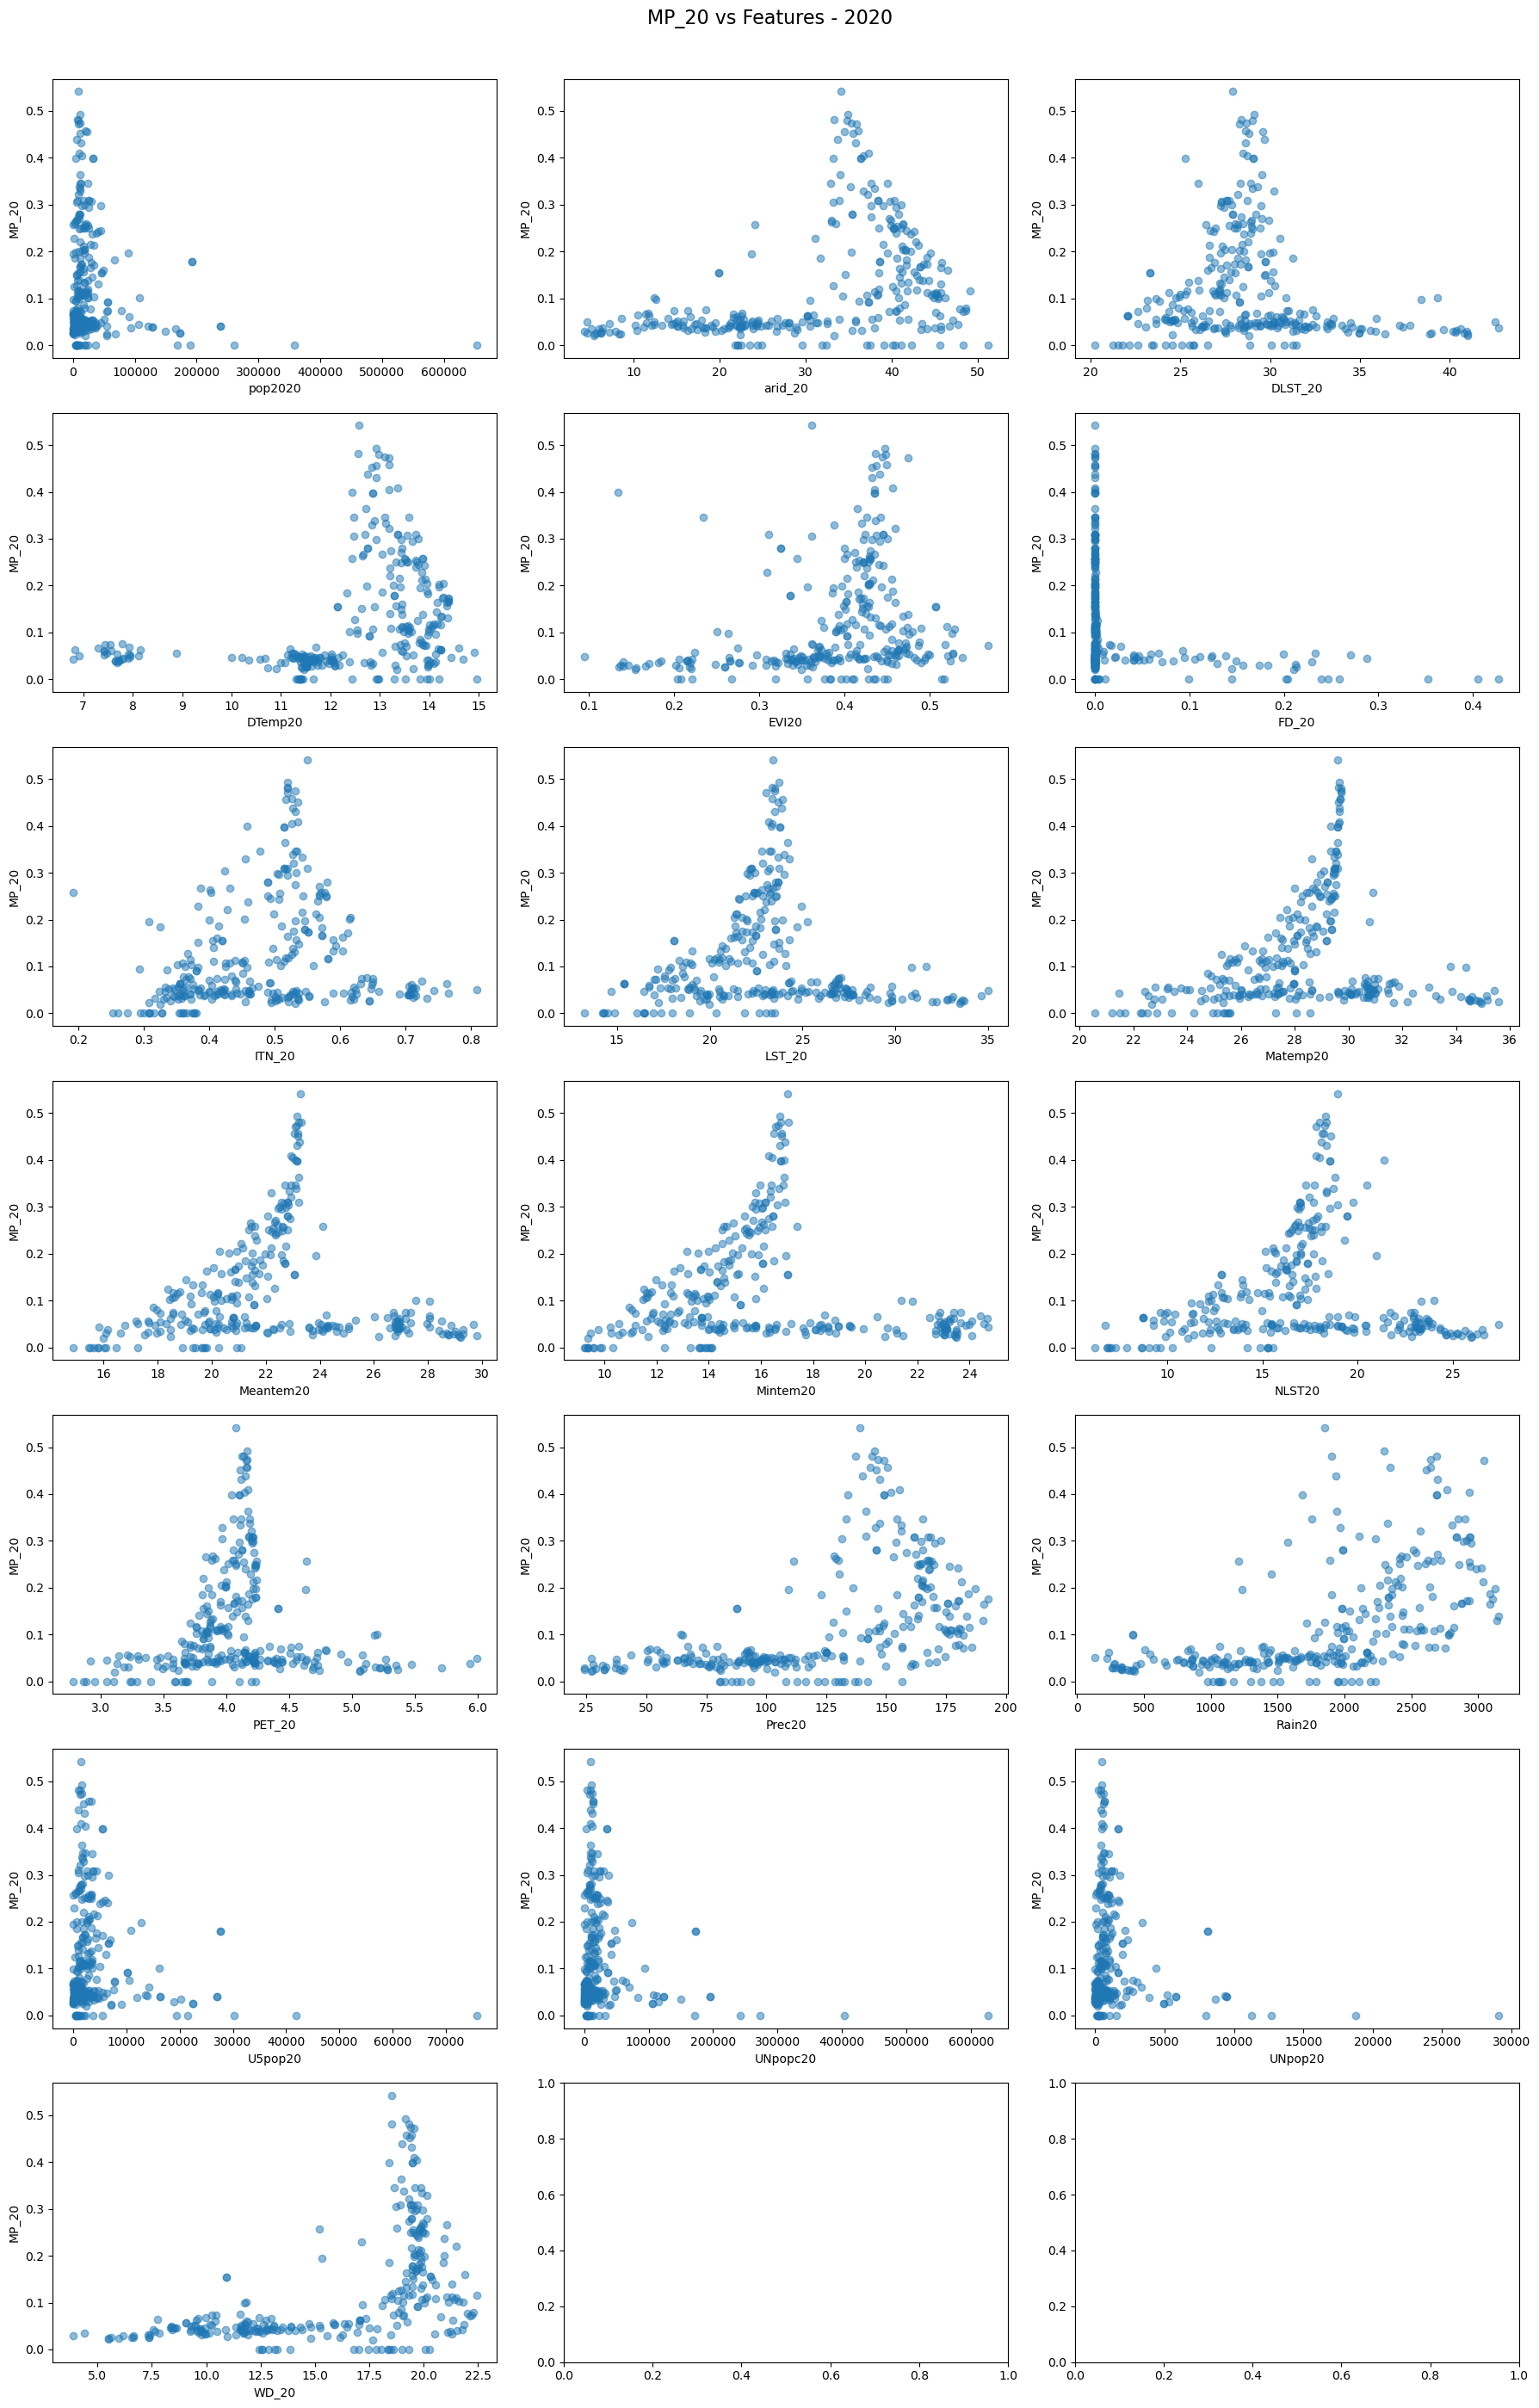

C:\Users\user\AppData\Local\Temp\ipykernel_7364\2164206489.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


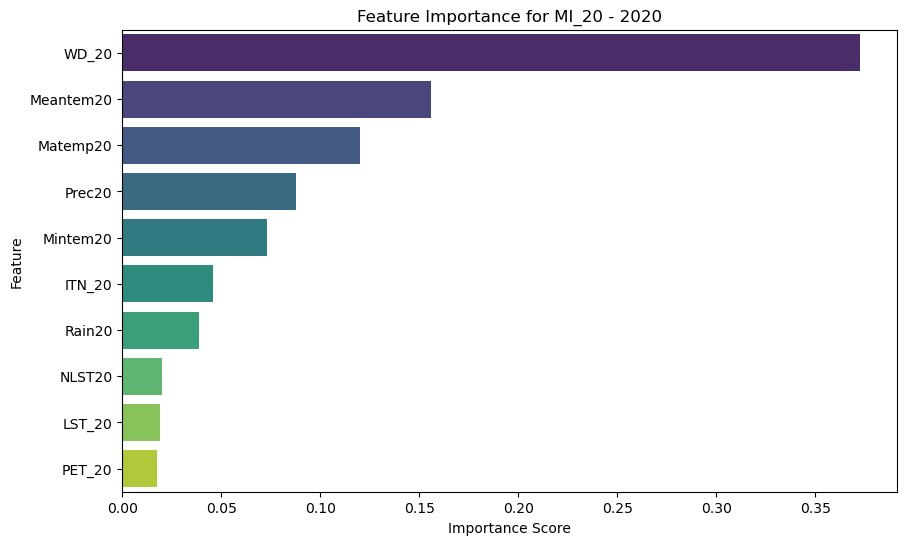

C:\Users\user\AppData\Local\Temp\ipykernel_7364\2164206489.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


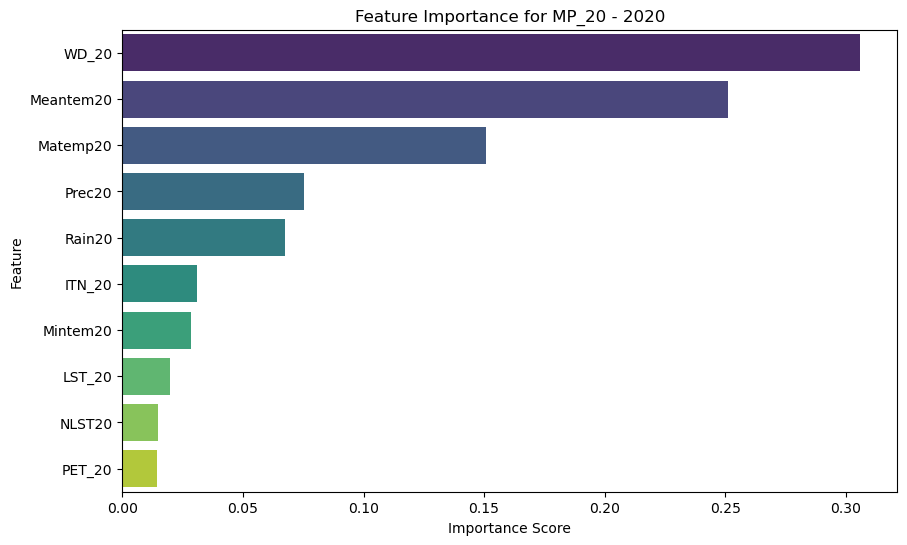

In [13]:
visualize_malaria_indicators(gdf, "2020")